# Working patch clamp data recorded during patterned optogenetic stimulation

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from mimo_pack.fileio.abf import load_abf_xr
from mimo_pack.fileio.image import load_images_xr
from mimo_pack.plot.map import wave_map_xr
from mimo_pack.plot.invitro import focal_stim_map
from mimo_pack.preprocess.invitro import focal_stimulation

In [2]:
abf_path = os.path.join('..','test_data','invitro','25707017.abf')
rec = load_abf_xr(abf_path)
print(rec)

<xarray.DataArray (time: 50000, channel: 4, trial: 100)> Size: 160MB
array([[[-63.8123, -64.2395, -63.5986, ..., -65.3687, -64.3921,
         -63.9343],
        [  1.2207,   6.7139,   4.2725, ...,  -3.6621, -10.376 ,
          -9.7656],
        [ -0.0012,  -0.0024,  -0.0027, ...,  -0.0031,  -0.0018,
          -0.0018],
        [  0.0031,   0.0024,   0.0027, ...,   0.0031,   0.0031,
           0.0027]],

       [[-63.6902, -64.209 , -63.6902, ..., -65.7654, -64.3005,
         -63.9038],
        [  4.2725,   4.8828,   2.4414, ..., -12.8174,  -9.7656,
          -7.9346],
        [ -0.0018,  -0.0024,  -0.0021, ...,  -0.0018,  -0.0021,
          -0.0021],
        [  0.0027,   0.0027,   0.0021, ...,   0.0015,   0.0027,
           0.0027]],

       [[-63.6902, -64.6057, -63.9954, ..., -65.3992, -64.3005,
         -63.8428],
...
        [  0.0021,   0.0027,   0.0031, ...,   0.0027,   0.0031,
           0.0027]],

       [[-64.27  , -64.0564, -64.6973, ..., -64.27  , -63.9954,
         -64.2395

In [3]:
imgs_path = os.path.join('..','test_data','invitro','single_squares')
patterns = load_images_xr(imgs_path, insert_blank=True)
print(patterns)

<xarray.DataArray (image: 50, y: 500, x: 835)> Size: 21MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
       

We have image stimuli that are spots of light projected around a patched cell. An easy way to visualize that is to color each frame a little different an than plot them stacked on one another.

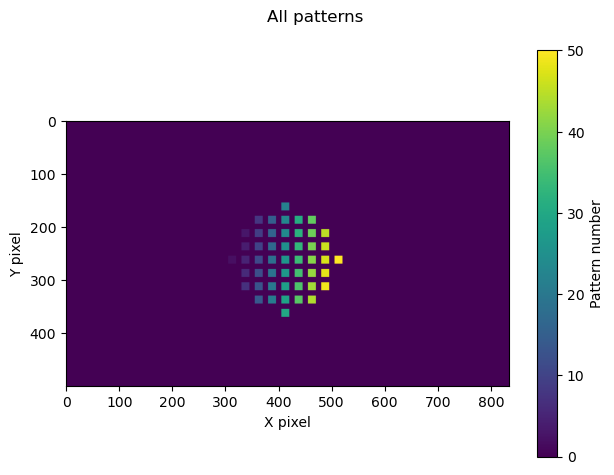

In [4]:
# gives each pattern a unique number
patterns_uniq = (patterns>0) * (np.arange(len(patterns))[:, None, None]+1)

# collapse all patterns for plotting
patterns_sum = patterns_uniq.sum(dim='image').to_numpy()

fig = plt.figure()
plt.imshow(patterns_sum, aspect='equal')
fig.suptitle('All patterns')
cbar = plt.colorbar()
cbar.set_label('Pattern number')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
fig.tight_layout()


We want to arrange our recorded responses based on where the light spot was shone. To identify those spots, we will find the center of mass for each image.

In [5]:
# for each image in imgs_xr, identify the x,y location of the center of mass. If no pixels are above 0, then return np.nan
def center_of_mass(image: np.ndarray) -> np.ndarray:
    """Calculate the center of mass of a 2D image."""
    if np.all(image == 0):
        return np.array([np.nan, np.nan])  # No pixels above 0

    y_indices, x_indices = np.indices(image.shape)
    total_mass = np.sum(image)

    if total_mass == 0:
        return np.array([np.nan, np.nan])  # Avoid division by zero

    y_center = np.sum(y_indices * image) / total_mass
    x_center = np.sum(x_indices * image) / total_mass

    return np.array([y_center, x_center])

# Apply the center_of_mass function to each image in the DataArray
centers = xr.apply_ufunc(
    center_of_mass,
    patterns,
    input_core_dims=[["y", "x"]],
    output_core_dims=[["center"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

# Assign coordinate names to the center dimension
centers = centers.assign_coords(center=["y", "x"])
print(centers)

<xarray.DataArray (image: 50, center: 2)> Size: 800B
array([[ nan,  nan],
       [262., 312.],
       [212., 337.],
       ...,
       [287., 487.],
       [312., 487.],
       [262., 512.]], shape=(50, 2))
Coordinates:
  * image       (image) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
    image_name  (image) <U21 4kB 'blank' ... 'single_square_049.bmp'
  * center      (center) <U1 8B 'y' 'x'


Now we have to add that spot location information into the recorded data xarray. We will add these as coordinates along the trial axis. Here we will use some information we know about the stimulation protocol used, which can be found in the xarray attribute `protocol`.

In [6]:
print('Our recording protocol was {}'.format(rec.attrs['protocol']))

# Extract the centers of mass for each pattern
stim_cents = centers.data

# add coordinate for stim_cents to iv
rec.coords['stim_x'] = ('trial', np.tile(stim_cents[:,0],2))
rec.coords['stim_y'] = ('trial', np.tile(stim_cents[:,1],2))

Our recording protocol was Left_StaticSeqLong_SingleCircle


In [7]:
rec

<xarray.DataArray (time: 50000, channel: 4, trial: 100)> Size: 160MB
array([[[-63.8123, -64.2395, -63.5986, ..., -65.3687, -64.3921,
         -63.9343],
        [  1.2207,   6.7139,   4.2725, ...,  -3.6621, -10.376 ,
          -9.7656],
        [ -0.0012,  -0.0024,  -0.0027, ...,  -0.0031,  -0.0018,
          -0.0018],
        [  0.0031,   0.0024,   0.0027, ...,   0.0031,   0.0031,
           0.0027]],

       [[-63.6902, -64.209 , -63.6902, ..., -65.7654, -64.3005,
         -63.9038],
        [  4.2725,   4.8828,   2.4414, ..., -12.8174,  -9.7656,
          -7.9346],
        [ -0.0018,  -0.0024,  -0.0021, ...,  -0.0018,  -0.0021,
          -0.0021],
        [  0.0027,   0.0027,   0.0021, ...,   0.0015,   0.0027,
           0.0027]],

       [[-63.6902, -64.6057, -63.9954, ..., -65.3992, -64.3005,
         -63.8428],
...
        [  0.0021,   0.0027,   0.0031, ...,   0.0027,   0.0031,
           0.0027]],

       [[-64.27  , -64.0564, -64.6973, ..., -64.27  , -63.9954,
         -64.2395],
        [  7.3242,  -1.8311,   4.8828, ...,  -8.5449,  -7.9346,
         -12.8174],
        [ -0.0024,  -0.0021,  -0.0021, ...,  -0.0027,  -0.0027,
          -0.0024],
        [  0.0024,   0.0027,   0.0027, ...,   0.0027,   0.0031,
           0.0027]],

       [[-64.2395, -63.7512, -64.6057, ..., -64.2395, -64.1785,
         -64.3616],
        [  8.5449,   0.6104,   6.7139, ..., -10.376 ,  -9.1553,
         -13.4277],
        [ -0.0024,  -0.0018,  -0.0027, ...,  -0.0024,  -0.0024,
          -0.0021],
        [  0.0027,   0.0027,   0.0027, ...,   0.0027,   0.0027,
           0.0031]]], shape=(50000, 4, 100))
Coordinates:
  * time      (time) float64 400kB 0.0 5e-05 0.0001 0.00015 ... 2.5 2.5 2.5 2.5
  * channel   (channel) int64 32B 0 1 2 3
  * trial     (trial) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    ch_names  (channel) <U7 112B 'Left 1' 'I' 'PlyTrig' 'LEDPow'
    ch_units  (channel) <U2 32B 'mV' 'pA' 'V' 'V'
    stim_x    (trial) float64 800B nan 262.0 212.0 237.0 ... 287.0 312.0 262.0
    stim_y    (trial) float64 800B nan 312.0 337.0 337.0 ... 487.0 487.0 512.0
Attributes:
    abf_file_path:  ..\test_data\invitro\25707017.abf
    abf_version:    2.6.0.0
    protocol:       Left_StaticSeqLong_SingleCircle
    sample_rate:    20000

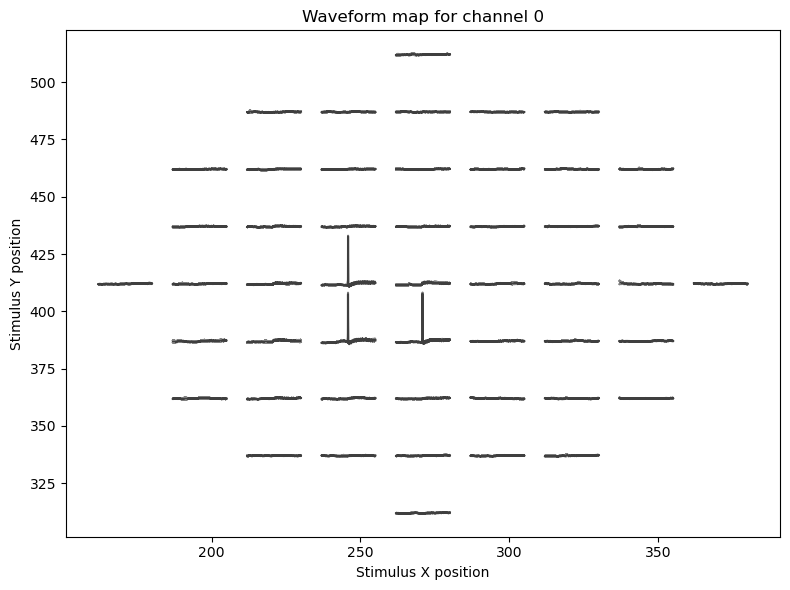

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
rec_plot = rec.sel(channel=0, time=slice(0.9, 1.2))
rec_plot = rec_plot - rec_plot.mean(dim='time')  # remove DC offset
wave_map_xr(rec_plot, x_coord='stim_x', y_coord='stim_y',
            x_scale=0.003, y_scale=.2, ax=ax, alpha=0.5)
ax.set_title('Waveform map for channel 0')
ax.set_xlabel('Stimulus X position')
ax.set_ylabel('Stimulus Y position')
fig.tight_layout()

## Using in vitro helper functions

In [6]:
rec

<xarray.DataArray (time: 50000, channel: 4, trial: 100)> Size: 160MB
array([[[-63.8123, -64.2395, -63.5986, ..., -65.3687, -64.3921,
         -63.9343],
        [  1.2207,   6.7139,   4.2725, ...,  -3.6621, -10.376 ,
          -9.7656],
        [ -0.0012,  -0.0024,  -0.0027, ...,  -0.0031,  -0.0018,
          -0.0018],
        [  0.0031,   0.0024,   0.0027, ...,   0.0031,   0.0031,
           0.0027]],

       [[-63.6902, -64.209 , -63.6902, ..., -65.7654, -64.3005,
         -63.9038],
        [  4.2725,   4.8828,   2.4414, ..., -12.8174,  -9.7656,
          -7.9346],
        [ -0.0018,  -0.0024,  -0.0021, ...,  -0.0018,  -0.0021,
          -0.0021],
        [  0.0027,   0.0027,   0.0021, ...,   0.0015,   0.0027,
           0.0027]],

       [[-63.6902, -64.6057, -63.9954, ..., -65.3992, -64.3005,
         -63.8428],
...
        [  0.0021,   0.0027,   0.0031, ...,   0.0027,   0.0031,
           0.0027]],

       [[-64.27  , -64.0564, -64.6973, ..., -64.27  , -63.9954,
         -64.2395],
        [  7.3242,  -1.8311,   4.8828, ...,  -8.5449,  -7.9346,
         -12.8174],
        [ -0.0024,  -0.0021,  -0.0021, ...,  -0.0027,  -0.0027,
          -0.0024],
        [  0.0024,   0.0027,   0.0027, ...,   0.0027,   0.0031,
           0.0027]],

       [[-64.2395, -63.7512, -64.6057, ..., -64.2395, -64.1785,
         -64.3616],
        [  8.5449,   0.6104,   6.7139, ..., -10.376 ,  -9.1553,
         -13.4277],
        [ -0.0024,  -0.0018,  -0.0027, ...,  -0.0024,  -0.0024,
          -0.0021],
        [  0.0027,   0.0027,   0.0027, ...,   0.0027,   0.0027,
           0.0031]]], shape=(50000, 4, 100))
Coordinates:
  * time      (time) float64 400kB 0.0 5e-05 0.0001 0.00015 ... 2.5 2.5 2.5 2.5
  * channel   (channel) int64 32B 0 1 2 3
  * trial     (trial) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    ch_names  (channel) <U7 112B 'Left 1' 'I' 'PlyTrig' 'LEDPow'
    ch_units  (channel) <U2 32B 'mV' 'pA' 'V' 'V'
    stim_x    (trial) float64 800B nan 262.0 212.0 237.0 ... 287.0 312.0 262.0
    stim_y    (trial) float64 800B nan 312.0 337.0 337.0 ... 487.0 487.0 512.0
Attributes:
    abf_file_path:  ..\test_data\invitro\25707017.abf
    abf_version:    2.6.0.0
    protocol:       Left_StaticSeqLong_SingleCircle
    sample_rate:    20000

In [3]:
rec

<xarray.DataArray (time: 50000, channel: 4, trial: 100)> Size: 160MB
array([[[-63.8123, -64.2395, -63.5986, ..., -65.3687, -64.3921,
         -63.9343],
        [  1.2207,   6.7139,   4.2725, ...,  -3.6621, -10.376 ,
          -9.7656],
        [ -0.0012,  -0.0024,  -0.0027, ...,  -0.0031,  -0.0018,
          -0.0018],
        [  0.0031,   0.0024,   0.0027, ...,   0.0031,   0.0031,
           0.0027]],

       [[-63.6902, -64.209 , -63.6902, ..., -65.7654, -64.3005,
         -63.9038],
        [  4.2725,   4.8828,   2.4414, ..., -12.8174,  -9.7656,
          -7.9346],
        [ -0.0018,  -0.0024,  -0.0021, ...,  -0.0018,  -0.0021,
          -0.0021],
        [  0.0027,   0.0027,   0.0021, ...,   0.0015,   0.0027,
           0.0027]],

       [[-63.6902, -64.6057, -63.9954, ..., -65.3992, -64.3005,
         -63.8428],
...
        [  0.0021,   0.0027,   0.0031, ...,   0.0027,   0.0031,
           0.0027]],

       [[-64.27  , -64.0564, -64.6973, ..., -64.27  , -63.9954,
         -64.2395],
        [  7.3242,  -1.8311,   4.8828, ...,  -8.5449,  -7.9346,
         -12.8174],
        [ -0.0024,  -0.0021,  -0.0021, ...,  -0.0027,  -0.0027,
          -0.0024],
        [  0.0024,   0.0027,   0.0027, ...,   0.0027,   0.0031,
           0.0027]],

       [[-64.2395, -63.7512, -64.6057, ..., -64.2395, -64.1785,
         -64.3616],
        [  8.5449,   0.6104,   6.7139, ..., -10.376 ,  -9.1553,
         -13.4277],
        [ -0.0024,  -0.0018,  -0.0027, ...,  -0.0024,  -0.0024,
          -0.0021],
        [  0.0027,   0.0027,   0.0027, ...,   0.0027,   0.0027,
           0.0031]]], shape=(50000, 4, 100))
Coordinates:
  * time      (time) float64 400kB 0.0 5e-05 0.0001 0.00015 ... 2.5 2.5 2.5 2.5
  * channel   (channel) int64 32B 0 1 2 3
  * trial     (trial) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    ch_names  (channel) <U7 112B 'Left 1' 'I' 'PlyTrig' 'LEDPow'
    ch_units  (channel) <U2 32B 'mV' 'pA' 'V' 'V'
Attributes:
    abf_file_path:  ..\test_data\invitro\25707017.abf
    abf_version:    2.6.0.0
    protocol:       Left_StaticSeqLong_SingleCircle
    sample_rate:    20000

<Axes: title={'center': 'Waveform map for channel 0'}, xlabel='Stimulus X position', ylabel='Stimulus Y position'>

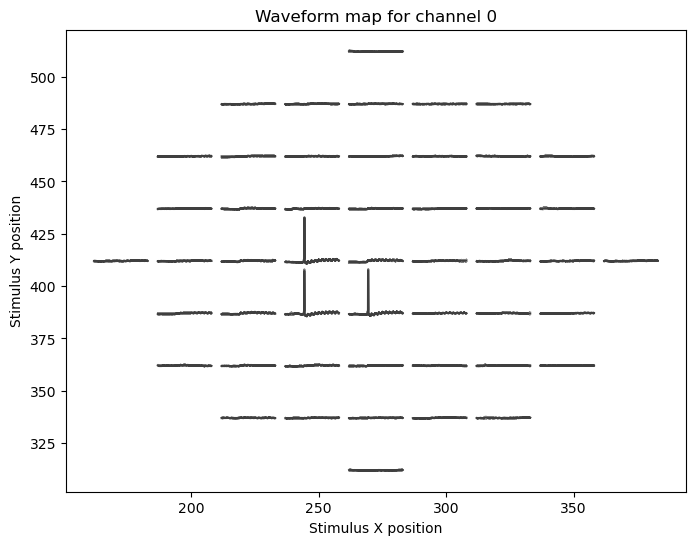

In [4]:
# Create file paths
imgs_path = os.path.join('..','test_data','invitro','single_squares')
abf_path = os.path.join('..','test_data','invitro','25707017.abf')

# Load the recording and patterns
rec = load_abf_xr(abf_path)
patterns = load_images_xr(imgs_path, insert_blank=True)

# Add stimulation locations to the recording
rec = focal_stimulation(rec, patterns)

fig, ax = plt.subplots(figsize=(8, 6))
focal_stim_map(rec, ax=ax, x_scale=0.007)


In [37]:
rec = load_abf_xr("D:\\BetaGamma\\project\\DH46\\Slice1\\Cell2\\25707011.abf")


(-1000.0, 1000.0)

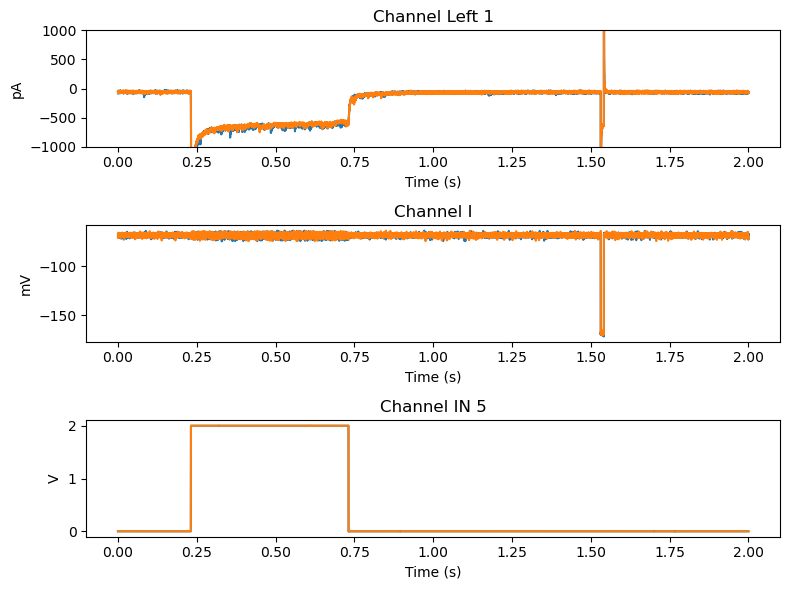

In [4]:
rec = load_abf_xr("D:\\BetaGamma\\project\\DH46\\Slice1\\Cell2\\25707012.abf")
chan_num = len(rec.channel)
fig, ax = plt.subplots(chan_num, 1, figsize=(8, 6))
for i in range(chan_num):
    ax[i].plot(rec.time, rec.sel(channel=i).data)
    ax[i].set_title('Channel {}'.format(rec['ch_names'][i].item()))
    ax[i].set_xlabel('Time (s)')
    ax[i].set_ylabel(rec['ch_units'][i].item())
fig.tight_layout()
ax[0].set_ylim(-1000,1000)